In [1]:
import numpy as np

def number_of_2T_chains(N_pre):
    return int(np.ceil(1.0 / N_pre))


def real_f_calc(N_pre, N_epsilon, _2T, N_eff=1000):
    _N_eff_factor = 2
    
    if N_pre < 1.0 - N_epsilon:
        #logger.info("2T x times bigger then Theta. (x is integer)")
        number_of_2T_chains = int(np.ceil(1.0 / N_pre))

        f_calc = number_of_2T_chains / _2T
        Theta = 1.0 / f_calc
        #logger.warning("Warning: approximated f_calc to: {0:.2f}".format(f_calc))
        #logger.warning("Number of chains: {0}".format(number_of_2T_chains))

    elif N_pre < 1.0 + N_epsilon:
        #logger.info("2T comparable with Theta so N becomes 1")
        f_calc = 1.0 / _2T
        Theta = _2T
        #logger.warning("Warning: approximated f_calc to: {0:.2f}".format(f_calc))

    else:
        N_max = _N_eff_factor * N_eff
        #logger.debug("N_max: {0}".format(N_max))
        if N_pre > N_max:
            #logger.info("N times Cavity decay time shorter than the sampling period")
            N = N_max
            f_calc = f_calc
            Theta = 1.0 / f_calc

            partial_Theta = True
        else:
            #logger.info("N times Cavity decay time longer than the sampling period")
            N = int(np.round(N_pre))
            Theta = _2T * N
            f_calc = 1.0 / Theta

    return f_calc, Theta

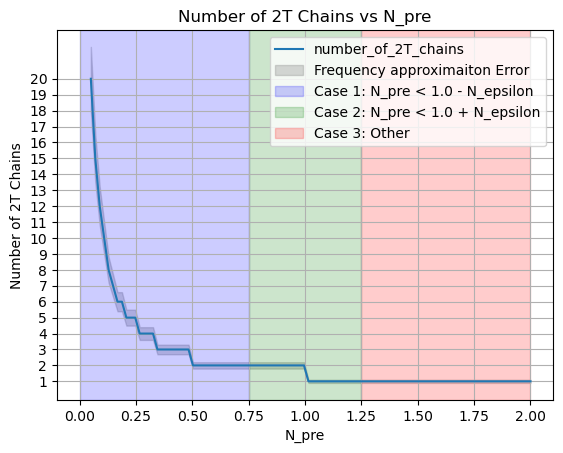

In [6]:
import matplotlib.pyplot as plt

# Define N_epsilon
N_epsilon = 0.25
_2T = 0.01
# Generate N_pre values
N_pre_values = np.linspace(0.05, 2, 100)

# Compute number_of_2T_chains for each N_pre
chains_values = [number_of_2T_chains(N_pre) for N_pre in N_pre_values]

# Compute f_calc and Theta for each N_pre
desired_f_calc_values = []
actual_f_calc_values = []
Theta_values = []
for N_pre in N_pre_values:
    desired_f_calc = 1./(N_pre * _2T)
    actual_f_calc, Theta = real_f_calc(N_pre, N_epsilon, _2T=_2T)
    desired_f_calc_values.append(desired_f_calc)
    actual_f_calc_values.append(actual_f_calc)
    Theta_values.append(Theta)

# Convert to numpy arrays for easier manipulation
desired_f_calc_values = np.array(desired_f_calc_values)
actual_f_calc_values = np.array(actual_f_calc_values)
Theta_values = np.array(Theta_values)

# Calculate the absolute error
f_calc_accuracy = np.abs(actual_f_calc_values - desired_f_calc_values) / desired_f_calc_values
    

# Plot the results
plt.plot(N_pre_values, chains_values, label='number_of_2T_chains')

# Define error margin (example: 10% of the chains_values)
error_margin = [0.1 * value for value in chains_values]

# Plot the error area
plt.fill_between(N_pre_values, 
                 [value - error for value, error in zip(chains_values, error_margin)], 
                 [value + error for value, error in zip(chains_values, error_margin)], 
                 color='gray', alpha=0.3, label='Frequency approximaiton Error')

# Add vertical color regions
plt.axvspan(0, 1.0 - N_epsilon, color='blue', alpha=0.2, label='Case 1: N_pre < 1.0 - N_epsilon')
plt.axvspan(1.0 - N_epsilon, 1.0 + N_epsilon, color='green', alpha=0.2, label='Case 2: N_pre < 1.0 + N_epsilon')
plt.axvspan(1.0 + N_epsilon, max(N_pre_values), color='red', alpha=0.2, label='Case 3: Other')

# Add labels and title
plt.xlabel('N_pre')
plt.ylabel('Number of 2T Chains')
plt.yticks(range(min(chains_values), max(chains_values) + 1))
plt.title('Number of 2T Chains vs N_pre')

# Add legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

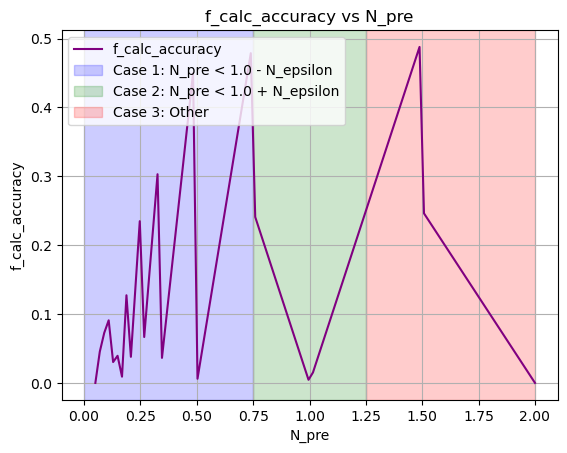

In [7]:
plt.plot(N_pre_values, f_calc_accuracy, label='f_calc_accuracy', color='purple')

# Add vertical color regions
plt.axvspan(0, 1.0 - N_epsilon, color='blue', alpha=0.2, label='Case 1: N_pre < 1.0 - N_epsilon')
plt.axvspan(1.0 - N_epsilon, 1.0 + N_epsilon, color='green', alpha=0.2, label='Case 2: N_pre < 1.0 + N_epsilon')
plt.axvspan(1.0 + N_epsilon, max(N_pre_values), color='red', alpha=0.2, label='Case 3: Other')


# Add labels and title
plt.xlabel('N_pre')
plt.ylabel('f_calc_accuracy')
plt.title('f_calc_accuracy vs N_pre')

# Add legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.show()